## Shah Hetvi Ileshkumar

### School Performance Segmentation 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("student-mat.csv")

In [3]:
df.head()

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.tail()

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   school                    395 non-null    str  
 1   sex                       395 non-null    str  
 2   age                       395 non-null    int64
 3   address                   395 non-null    str  
 4   famsize                   395 non-null    str  
 5   Parrent_status            395 non-null    str  
 6   Mother_edu                395 non-null    int64
 7   Father_edu                395 non-null    int64
 8   Mother_job                395 non-null    str  
 9   Father_job                395 non-null    str  
 10  reason_to_chose_school    395 non-null    str  
 11  guardian                  395 non-null    str  
 12  traveltime                395 non-null    int64
 13  weekly_studytime          395 non-null    int64
 14  failures                  395 non-null    int64
 15  

In [6]:
df.isnull().sum()

school                      0
sex                         0
age                         0
address                     0
famsize                     0
Parrent_status              0
Mother_edu                  0
Father_edu                  0
Mother_job                  0
Father_job                  0
reason_to_chose_school      0
guardian                    0
traveltime                  0
weekly_studytime            0
failures                    0
extra_edu_supp              0
family_edu_supp             0
extra_paid_class            0
extra_curr_activities       0
nursery                     0
Interested_in_higher_edu    0
internet_access             0
romantic_relationship       0
Family_quality_reln         0
freetime_after_school       0
goout_with_friends          0
workday_alcohol_consum      0
weekend_alcohol_consum      0
health_status               0
absences                    0
G1                          0
G2                          0
G3                          0
dtype: int

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Mother_edu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Father_edu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
weekly_studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
Family_quality_reln,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime_after_school,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout_with_friends,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
workday_alcohol_consum,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


In [10]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Parrent_status',
       'Mother_edu', 'Father_edu', 'Mother_job', 'Father_job',
       'reason_to_chose_school', 'guardian', 'traveltime', 'weekly_studytime',
       'failures', 'extra_edu_supp', 'family_edu_supp', 'extra_paid_class',
       'extra_curr_activities', 'nursery', 'Interested_in_higher_edu',
       'internet_access', 'romantic_relationship', 'Family_quality_reln',
       'freetime_after_school', 'goout_with_friends', 'workday_alcohol_consum',
       'weekend_alcohol_consum', 'health_status', 'absences', 'G1', 'G2',
       'G3'],
      dtype='str')


In [12]:
X = df[['weekly_studytime','failures','absences','G1','G2','G3']]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
wcss = []

In [15]:
for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

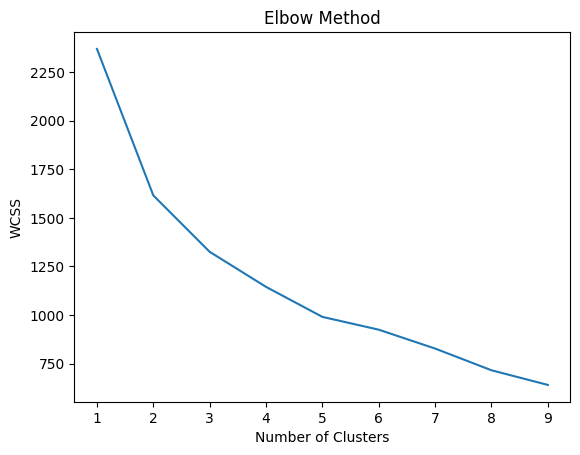

In [16]:
plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)

In [18]:
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [19]:
df.head()

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3,Cluster
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,2
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,0


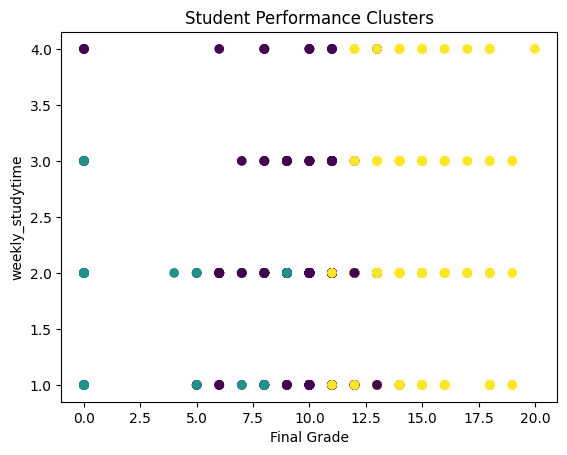

In [22]:
plt.scatter(df['G3'], df['weekly_studytime'], c=df['Cluster'])
plt.xlabel("Final Grade")
plt.ylabel("weekly_studytime")
plt.title("Student Performance Clusters")
plt.show()

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [24]:
linked = linkage(X_scaled, method='ward')

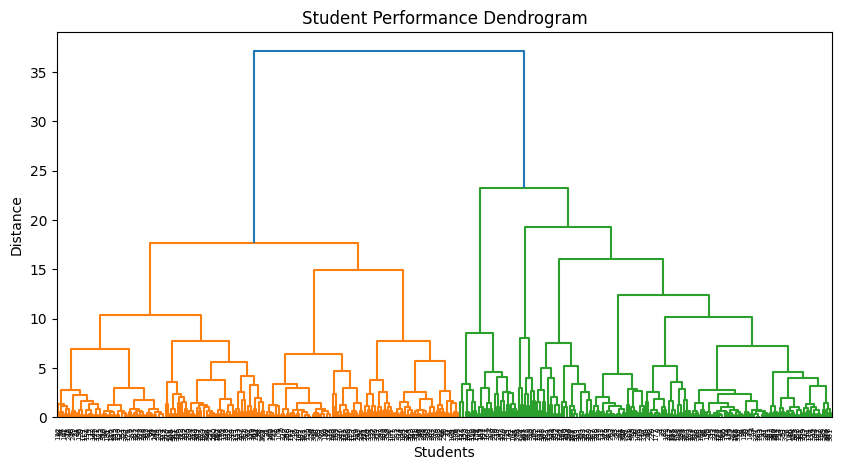

In [25]:
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Student Performance Dendrogram")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.show()

In [26]:
model = AgglomerativeClustering(n_clusters=3)
df['Cluster'] = model.fit_predict(X_scaled)

print(df.head())

  school sex  age address famsize Parrent_status  Mother_edu  Father_edu  \
0     GP   F   18       U     GT3              A           4           4   
1     GP   F   17       U     GT3              T           1           1   
2     GP   F   15       U     LE3              T           1           1   
3     GP   F   15       U     GT3              T           4           2   
4     GP   F   16       U     GT3              T           3           3   

  Mother_job Father_job  ... freetime_after_school goout_with_friends  \
0    at_home    teacher  ...                     3                  4   
1    at_home      other  ...                     3                  3   
2    at_home      other  ...                     3                  2   
3     health   services  ...                     2                  2   
4      other      other  ...                     3                  2   

   workday_alcohol_consum  weekend_alcohol_consum  health_status absences  G1  \
0                      

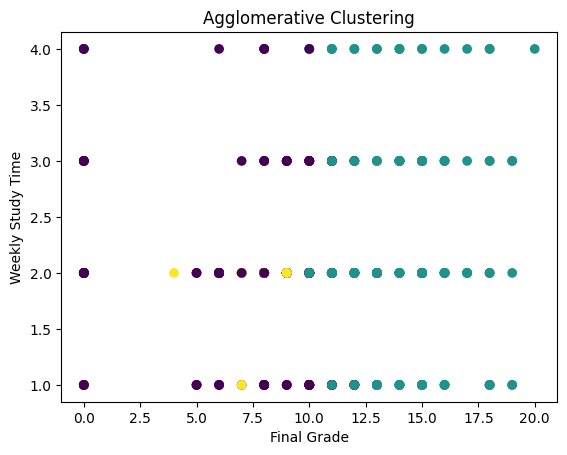

In [27]:
plt.scatter(df['G3'], df['weekly_studytime'], c=df['Cluster'])
plt.xlabel("Final Grade")
plt.ylabel("Weekly Study Time")
plt.title("Agglomerative Clustering")
plt.show()